### Imports and Environment Configuration
This section imports the necessary libraries for:
*   **Web Scraping & Browser Automation:** `selenium`, `webdriver_manager`, `bs4`.
*   **Vector Database & Embeddings:** `langchain`, `FAISS`, `HuggingFaceEmbeddings`.
*   **Agent Orchestration:** `langgraph` for managing the flow between agents.
*   **PDF Parsing:** `scipdf` to extract text and structure from research papers.
*   **UI:** `gradio` for the frontend interface.

It also loads environment variables (like API keys) and initializes the embedding model used to vectorize text chunks.

In [1]:
import time
import re
import glob
import shutil
import base64
import json
from typing import Annotated, TypedDict, Literal
from IPython.display import Image, display
from selenium import webdriver
from selenium.webdriver.chrome.service import Service
from webdriver_manager.chrome import ChromeDriverManager
from bs4 import BeautifulSoup
import os
import warnings
warnings.filterwarnings('ignore')
os.environ["TOKENIZERS_PARALLELISM"] = "false"

In [2]:
from langchain.embeddings import HuggingFaceEmbeddings
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langchain_core.messages import AIMessage, HumanMessage
from langchain_community.vectorstores import FAISS
from langchain.docstore.document import Document
from langchain.vectorstores import FAISS
import scipdf
from langchain_core.documents import Document
from langchain.vectorstores import FAISS
from langchain_community.embeddings import HuggingFaceEmbeddings
from langchain_openai import ChatOpenAI
import gradio as gr ###

In [3]:
from dotenv import load_dotenv

load_dotenv()

True

### PDF Ingestion and Vector Indexing
These functions handle the processing of local PDF files:
1.  **`extract_authors`**: Helper to format author metadata.
2.  **`load_and_index_pdfs`**:
    *   Iterates through a specified folder.
    *   Uses `scipdf` to parse the PDF structure (abstracts, sections, headers).
    *   Creates document chunks for both the full summary and individual sections.
    *   Builds a **FAISS** vector index using HuggingFace embeddings for semantic retrieval.

Ensure the `scipdf` library is properly configured (it requires a Grobid server running locally - more detailed instruction in README.md).

In [ ]:
embeddings = HuggingFaceEmbeddings(model_name="sentence-transformers/all-MiniLM-L6-v2")

def extract_authors(authors_raw):
    if isinstance(authors_raw, list):
        return ", ".join(a.get("name") or a.get("full_name", "") 
                         for a in authors_raw if isinstance(a, dict))
    return str(authors_raw or "")

def load_and_index_pdfs(pdf_folder):
    chunks, title_to_meta = [], {}

    for filename in sorted(os.listdir(pdf_folder)):
        if not filename.lower().endswith(".pdf"):
            continue
        pdf_path = os.path.join(pdf_folder, filename)
        try:
            article = scipdf.parse_pdf_to_dict(pdf_path)
        except Exception as e:
            print(f"Failed {filename}: {e}")
            continue

        title = article.get("title") or filename
        authors = extract_authors(article.get("authors"))
        abstract = article.get("abstract", "")
        pub_date = article.get("pub_date", "")
        doc_id = os.path.splitext(filename)[0]

        title_norm = title.strip().lower()
        title_to_meta[title_norm] = {
            "title": title,
            "authors": authors,
            "abstract": abstract,
            "pub_date": pub_date,
            "filename": filename
        }

        summary = f"Title: {title}\nAuthors: {authors}\nAbstract: {abstract}\nPubDate: {pub_date}"
        summary_doc = Document(
            page_content=summary,
            metadata={
                "source": filename,
                "doc_id": doc_id,
                "title": title,
                "authors": authors,
                "pub_date": pub_date,
                "type": "summary"
            }
        )
        chunks.append(summary_doc)
        print("\nAdded SUMMARY chunk:")
        print(summary_doc.page_content[:400], "...")
        print("Metadata:", summary_doc.metadata)

        sections = article.get("sections") or []
        for idx, sec in enumerate(sections, 1):
            heading = sec.get("heading") or f"Section {idx}"
            body = sec.get("text") or ""
            if not body.strip():
                continue
            sec_doc = Document(
                page_content=f"{heading}\n{body}",
                metadata={
                    "source": filename,
                    "doc_id": doc_id,
                    "title": title,
                    "authors": authors,
                    "pub_date": pub_date,
                    "section": heading,
                    "type": "section"
                }
            )
            chunks.append(sec_doc)
            print("\nAdded SECTION chunk:")
            print(sec_doc.page_content[:400], "...")
            print("Metadata:", sec_doc.metadata)

    print(f"\nTotal chunks collected: {len(chunks)}")

    if not chunks:
        print("No chunks created, skipping FAISS build.")
        return None, title_to_meta

    vectordb = FAISS.from_documents(chunks, embeddings)
    print("FAISS index built.")
    return vectordb, title_to_meta

vectordb, title_to_meta = load_and_index_pdfs("small_input_deepsake")




/var/folders/sp/c8vrf2jn3lx8_8z16kc3zg540000gn/T/ipykernel_13853/1145103209.py:1: LangChainDeprecationWarning: The class `HuggingFaceEmbeddings` was deprecated in LangChain 0.2.2 and will be removed in 1.0. An updated version of the class exists in the :class:`~langchain-huggingface package and should be used instead. To use it run `pip install -U :class:`~langchain-huggingface` and import as `from :class:`~langchain_huggingface import HuggingFaceEmbeddings``.
  embeddings = HuggingFaceEmbeddings(model_name="sentence-transformers/all-MiniLM-L6-v2")



Added SUMMARY chunk:
Title: Playing Atari with Deep Reinforcement Learning
Authors: Volodymyr Mnih; Koray Kavukcuoglu; David Silver; Alex Graves; Ioannis Antonoglou; Daan Wierstra; Martin Riedmiller
Abstract: We present the first deep learning model to successfully learn control policies directly from high-dimensional sensory input using reinforcement learning. The model is a convolutional neural network, trained with ...
Metadata: {'source': '1312.5602v1.pdf', 'doc_id': '1312.5602v1', 'title': 'Playing Atari with Deep Reinforcement Learning', 'authors': 'Volodymyr Mnih; Koray Kavukcuoglu; David Silver; Alex Graves; Ioannis Antonoglou; Daan Wierstra; Martin Riedmiller', 'pub_date': '2013-12-19', 'type': 'summary'}

Added SECTION chunk:
Introduction
Learning to control agents directly from high-dimensional sensory inputs like vision and speech is one of the long-standing challenges of reinforcement learning (RL). Most successful RL applications that operate on these domains have relied

### Web Scraping (GRADE Book)
This section handles the retrieval of external knowledge from the GRADE Book website.
*   **`fetch_visible_text_from_web`**: Uses a headless Selenium Chrome browser to render JavaScript-heavy pages and extracts visible text using BeautifulSoup.
*   **`fetch_all_grade_text`**: Iterates through a list of specific URLs to build a concatenated text corpus.

This allows the bot to answer questions based on the latest online guidelines in addition to static PDFs.

In [5]:
def fetch_visible_text_from_web(url: str, wait_time: int = 5) -> str:
    options = webdriver.ChromeOptions()
    options.add_argument('--headless')
    driver = webdriver.Chrome(service=Service(ChromeDriverManager().install()), options=options)
    driver.get(url)
    time.sleep(wait_time)
    page_source = driver.page_source
    driver.quit()

    soup = BeautifulSoup(page_source, "html.parser")
    for script in soup(["script", "style"]):
        script.decompose()

    visible_text = soup.get_text(separator="\n", strip=True)
    visible_text = visible_text.replace("\xa0", " ")
    visible_text = re.sub(r"\s+", " ", visible_text)

    visible_text = visible_text.replace("GRADE Book You need to enable JavaScript to run this app.", "")
    visible_text = visible_text.strip()

    return visible_text

### Context Construction and LLM Setup
*   **`create_context`**: Aggregates information from enabled sources (PDF Vector DB and/or Web Text) based on the user's query.
*   **`llm`**: Initializes the Chat Model (via OpenRouter) which will act as the reasoning engine.
*   **`RESEARCHBOT_SYSINT`**: The **System Prompt**. This is crucial as it instructs the bot to:
    *   Act as a scientific assistant.
    *   Strictly base answers on retrieved context (preventing hallucinations).
    *   Pay attention to figure/table metadata.

In [6]:
grade_urls = [
    "https://book.gradepro.org/guideline/overview-of-the-grade-approach",
    "https://book.gradepro.org/guideline/the-development-methods-of-grade",
    "https://book.gradepro.org/guideline/requirements-for-claiming-the-use-of-grade",
    "https://book.gradepro.org/guideline/questions-about-interventions-diagnostic-test-prognosis-and-exposures",
    "https://book.gradepro.org/guideline/risk-of-bias-randomized-trials",
    "https://book.gradepro.org/guideline/inconsistency",
    "https://book.gradepro.org/guideline/imprecision",
    "https://book.gradepro.org/guideline/dissemination-bias"
]

def fetch_all_grade_text(urls, wait_time=5):
    all_texts = []
    for url in urls:
        print(f"Fetching: {url}")
        text = fetch_visible_text_from_web(url, wait_time=wait_time)
        all_texts.append(text)
    return "\n\n".join(all_texts)

grade_book_text = fetch_all_grade_text(grade_urls)

def create_context(query: str, sources: dict) -> str:
    """
    sources: dict with keys as source names and values as retrieval functions
    """
    context_parts = []
    for name, fetch_func in sources.items():
        print(f"Fetching from {name}...")
        context = fetch_func(query)
        context_parts.append(f"Source: {name}\n{context}")
    return "\n\n".join(context_parts)

'''sources = {
    "PDFs": lambda q: "\n".join([doc.page_content for doc in vectordb.similarity_search(q, k=5)]),
    "GRADE Book": lambda q: grade_book_text
}'''
'''
sources = {
    "PDFs": lambda q: "\n".join([doc.page_content for doc in vectordb.similarity_search(q, k=5)])
}'''
sources = {
    "GRADE Book": lambda q: grade_book_text
}


Fetching: https://book.gradepro.org/guideline/overview-of-the-grade-approach
Fetching: https://book.gradepro.org/guideline/the-development-methods-of-grade
Fetching: https://book.gradepro.org/guideline/requirements-for-claiming-the-use-of-grade
Fetching: https://book.gradepro.org/guideline/questions-about-interventions-diagnostic-test-prognosis-and-exposures
Fetching: https://book.gradepro.org/guideline/risk-of-bias-randomized-trials
Fetching: https://book.gradepro.org/guideline/inconsistency
Fetching: https://book.gradepro.org/guideline/imprecision
Fetching: https://book.gradepro.org/guideline/dissemination-bias


In [7]:
llm = ChatOpenAI(
    base_url="https://openrouter.ai/api/v1",
    api_key=os.getenv("OPENROUTER_API_KEY"),
    model=os.getenv("MODEL_NAME")
)

### State Definition and Multimodal Processing
This section defines the "Brain" of the agentic workflow.
*   **`QAState`**: A TypedDict that acts as the shared memory between agents, tracking the query, retrieved documents, figures status, and conversation history.
*   **Figure/Table Analysis**:
    *   **`save_pdf_to_title_map`**: Maps filenames to paper titles for better citation.
    *   **`get_figures...`**: Extracts images from PDFs.
    *   **`analyze_figures...`**: Uses a Vision-Language Model (VLM) (e.g., `nemotron-nano`) to generate text descriptions of charts and tables.
    *   **`add_description...`**: Indexes these image descriptions into the Vector DB so they can be retrieved via semantic search.

In [8]:
RESEARCHBOT_SYSINT = (
    "system",
    "You are ResearchBot, an intelligent assistant that helps users understand and explore scientific information "
    "from multiple sources, such as research articles (PDFs), guideline websites (e.g., GRADE Book), and other authoritative resources. "
    "A human will ask you questions about the content of these sources, and you will answer based only on the information retrieved from them."
    "\n\n"
    "Use the retriever tool to search the most relevant sources for the user's query. Limit your answers strictly to facts and details "
    "supported directly by the retrieved content. You may paraphrase, summarize, and structure information, but do not fabricate or speculate "
    "beyond what is found in the sources. If you are unsure or the sources do not contain enough information, clearly state that you don't have "
    "a confident answer based on the available data."
    "\n\n"
    "Pay close attention to the metadata of retrieved chunks. For example:\n"
    "- If a chunk has 'type' set to 'figure_description', it contains information about a figure or table.\n"
    "- If a chunk has a 'figure' field, it indicates the exact numbering in the original paper (e.g., 'Figure1', 'Table3').\n"
    "  Use this to match the user's question precisely — for example, if the user asks about 'Figure 3', prefer chunks with 'figure':'Figure3'.\n"
    "\n"
    "While answering do not use general knowledge, so if the answer can't be given based only on provided context, say that you are unable to answer."
    "\n\n"
    "If retrieval fails or tools are unavailable, inform the user that the system needs further setup."
)

WELCOME_MSG = "Welcome to ResearchBot! You can ask questions about scientific topics, guidelines, or research articles. Type your question to begin, or type `Goodbye` to quit."


class QAState(TypedDict):
    messages: Annotated[list, add_messages]
    query: str
    context: str
    retrieved_docs: list
    answer: str
    finished: bool
    figures_retrieved: bool 

### Agent Functions (Nodes)
These are the executable nodes of the LangGraph:
1.  **`images_table_agent`**: Checks if figure analysis is needed. If so, extracts images, generates descriptions, and updates the vector index dynamically.
2.  **`retriever_agent`**: Performs similarity search on the Vector DB and fetches web context.
3.  **`answer_generator_agent`**: Constructs the final prompt with context and queries the LLM for the answer.
4.  **`human_node`**: (Optional) For CLI-based interaction loop.

In [ ]:
def save_pdf_to_title_map(pdf_folder, output_json="pdf_to_title.json"):
    mapping = {}
    for filename in sorted(os.listdir(pdf_folder)):
        if not filename.lower().endswith(".pdf"):
            continue
        pdf_path = os.path.join(pdf_folder, filename)
        try:
            article = scipdf.parse_pdf_to_dict(pdf_path)
            title = article.get("title") or filename
        except Exception as e:
            print(f"Failed {filename}: {e}")
            title = filename
        mapping[filename] = title
    with open(output_json, "w") as f:
        json.dump(mapping, f, indent=2)
    print(f"Saved PDF-to-title mapping to {output_json}")

def get_figures_and_tables_from_papers(output, full_path):
    if os.path.isfile(full_path):
        scipdf.parse_figures(full_path, output_folder=output)
        print(full_path + " finished")


def analyze_figures_and_tables(folder, output_folder):
    llm = ChatOpenAI(
    base_url="https://openrouter.ai/api/v1",
    api_key=os.getenv("OPENROUTER_API_KEY"),
    model="nvidia/nemotron-nano-12b-v2-vl")
    responses = []
    os.makedirs(output_folder, exist_ok=True)

    for filename in os.listdir(folder):
        full_path = os.path.join(folder, filename)
        if os.path.isfile(full_path) and filename.lower().endswith(".png"):
            with open(full_path, "rb") as f:
                image_bytes = f.read()

            image_b64 = base64.b64encode(image_bytes).decode("utf-8")

            response = llm.invoke([
                HumanMessage(content=[
                    {"type": "input_text", "text": "Identify the image type (photograph/line plot/bar chart/heatmap/table/diagram). Extract any visible text (caption, labels, legend entries) exactly as shown. For plots: list each axis label and units, the plotted variables and legend entries; describe the main trends, peaks, slopes, comparisons between series, and any statistical annotations. For tables: list column and row headers, units, and 5 to 10 representative numeric rows or important cells. Note anomalies, data ranges, and approximate numeric values for key features. Give a detailed and analytics-focused descriptiom of images. If information is unreadable or not present, say 'NOT_VISIBLE' for that field. Do not invent facts."},
                    {"type": "image_url", "image_url": {"url": f"data:image/png;base64,{image_b64}"}}
                ])
            ])

            description = response.content if hasattr(response, "content") else str(response)
            print(description)
            responses.append(description)

            name = re.sub(r"\.png$", "", filename, flags=re.IGNORECASE)
            with open(os.path.join(output_folder, name + ".txt"), "w") as f:
                f.write(description)

    return responses


def should_include_figures(query: str) -> bool:
    keywords = ["figure", "table", "diagram", "image", "plot", "chart"]
    return any(kw in query.lower() for kw in keywords)


def add_description_chunks_to_vectordb(descriptions_folder, vectordb):
    pdf_map_path = "pdf_to_title.json"
    if os.path.exists(pdf_map_path):
        with open(pdf_map_path, "r") as f:
            pdf_to_title = json.load(f)
        print(f"Loaded pdf_to_title.json with {len(pdf_to_title)} entries.")
    else:
        pdf_to_title = {}
        print("No pdf_to_title.json found. Proceeding without PDF title metadata.")

    new_chunks = []
    for filename in os.listdir(descriptions_folder):
        if filename.endswith(".txt"):
            with open(os.path.join(descriptions_folder, filename), "r") as f:
                description = f.read().strip()

            name_no_ext = filename.rsplit(".", 1)[0]
            base_pdf_name = name_no_ext.split("-", 1)[0] + ".pdf"
            image_number = name_no_ext.split("_", 1)[0].split("-", 1)[1].split("-", 1)[0]
            paper_title = pdf_to_title.get(base_pdf_name, "")
            meta = {
                "source": base_pdf_name,
                "title": paper_title,
                "figure": image_number,
                "type": "figure_description"
            }
            doc = Document(
                page_content=description,
                metadata=meta
            )
            print("\nAdded VISUAL chunk:")
            print(doc.page_content[:100], "...")
            print("Metadata:", doc.metadata)
            new_chunks.append(doc)
    if new_chunks:
        vectordb.add_documents(new_chunks)
        print(f"Added {len(new_chunks)} image description chunks to vectordb.")
    else:
        print("No new chunks to add to vectordb.")
        

def images_table_agent(state: QAState) -> QAState:
    if state.get("figures_retrieved", False):
        return state
    

    figures_folder = "outputs/images"
    descriptions_folder = "outputs/descriptions"
    pdf_dir = "small_input_deepsake"

    save_pdf_to_title_map(pdf_dir)


    shutil.rmtree(figures_folder, ignore_errors=True)
    os.makedirs(figures_folder, exist_ok=True)

    for pdf_path in glob.glob(os.path.join(pdf_dir, "*.pdf")):
        get_figures_and_tables_from_papers(figures_folder, pdf_path)

    analyze_figures_and_tables("outputs/images/figures", descriptions_folder)
    add_description_chunks_to_vectordb(descriptions_folder, vectordb)

    state["figures_retrieved"] = True
    return state



### Graph Orchestration
This section wires the agents together using `StateGraph`.
*   **Nodes**: Registers the agents defined above.
*   **Edges**: Defines the flow logic (e.g., `images_table_agent` -> `retriever_agent` -> `answer_generator_agent`).
*   **Conditionals**: The `next_human_edge` determines if the workflow requires figure extraction based on the user's query keywords (e.g., "show me the plot").

In [10]:
def retriever_agent(state: QAState) -> QAState:
    query = state["query"]
    context = create_context(query, sources)
    return state | {"context": context}

def answer_generator_agent(state: QAState) -> QAState:
    context = state["context"]
    prompt = f"Answer the following question based on the context:\n\nContext:\n{context}\n\nQuestion: {state['query']}"

    response = llm.invoke(prompt)
    answer = response.content

    return state | {
        "answer": answer,
        "messages": state["messages"] + [AIMessage(content=answer)]
    }
 
def human_node(state: QAState) -> QAState:
    if state["messages"]:
        print("Model:", state["messages"][-1].content)
    else:
        print("Model:", WELCOME_MSG)

    user_input = input("User: ").strip()

    if user_input.lower() in {"q", "quit", "exit", "goodbye"}:
        return state | {"finished": True}

    human_msg = HumanMessage(content=user_input)
    return state | {"messages": state["messages"] + [human_msg], "query": user_input, "finished": False}


def next_human_edge(state: QAState) -> Literal["images_table_agent", "retriever_agent", "__end__"]:
    if state.get("finished", False):
        return END
    if should_include_figures(state.get("query", "")) and not state.get("figures_retrieved", False):
        return "images_table_agent"
    return "retriever_agent"


graph_builder = StateGraph(QAState)

graph_builder.add_node("images_table_agent", images_table_agent)
graph_builder.add_node("retriever_agent", retriever_agent)
graph_builder.add_node("answer_generator_agent", answer_generator_agent)
graph_builder.add_node("human", human_node)

graph_builder.add_edge(START, "human")
graph_builder.add_conditional_edges("human", next_human_edge)
graph_builder.add_edge("images_table_agent", "retriever_agent")
graph_builder.add_edge("retriever_agent", "answer_generator_agent")
graph_builder.add_edge("answer_generator_agent", "human")

qa_graph = graph_builder.compile()

initial_state = {
    "messages": [AIMessage(content=WELCOME_MSG)],
    "query": "",
    "retrieved_docs": [],
    "answer": "",
    "finished": False,
    "figures_retrieved": False,
}

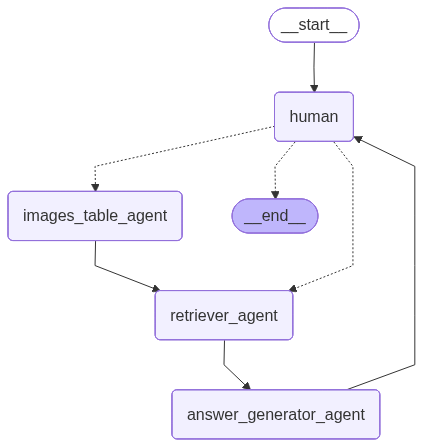

In [11]:
Image(qa_graph.get_graph().draw_mermaid_png())

In [12]:
final_state = qa_graph.invoke(initial_state)

Model: Welcome to ResearchBot! You can ask questions about scientific topics, guidelines, or research articles. Type your question to begin, or type `Goodbye` to quit.
Saved PDF-to-title mapping to pdf_to_title.json
Done parsing figures from PDFs!
/Users/ukostuch/Documents/THESIS/small_input_deepsake/1606.05328.pdf finished
Done parsing figures from PDFs!
/Users/ukostuch/Documents/THESIS/small_input_deepsake/1412.5903v5.pdf finished
Done parsing figures from PDFs!
/Users/ukostuch/Documents/THESIS/small_input_deepsake/1611.06310.pdf finished
Done parsing figures from PDFs!
/Users/ukostuch/Documents/THESIS/small_input_deepsake/1511.05946v3.pdf finished
Done parsing figures from PDFs!
/Users/ukostuch/Documents/THESIS/small_input_deepsake/1902.02257v2.pdf finished
Done parsing figures from PDFs!
/Users/ukostuch/Documents/THESIS/small_input_deepsake/1402.0030v2.pdf finished
Done parsing figures from PDFs!
/Users/ukostuch/Documents/THESIS/small_input_deepsake/2302.04798.pdf finished
Done par

### Functions used by evaluation script

In [ ]:
def ask_chatbot(question: str) -> str:
    state = {
        "messages": [AIMessage(content=WELCOME_MSG)],
        "query": question,
        "retrieved_docs": [],
        "answer": "",
        "finished": False,
        "figures_retrieved": False,
    }
    if should_include_figures(question) and not state["figures_retrieved"]:
        state = images_table_agent(state)
    state = retriever_agent(state)
    state = answer_generator_agent(state)
    return state["answer"]

In [14]:
def get_retrieved_contexts(query: str, source_key: str = "PDFs", k: int = 5) -> list:
    if source_key not in sources:
        raise ValueError(f"Source '{source_key}' not found in sources dictionary.")
    if source_key == "PDFs":
        docs = vectordb.similarity_search(query, k=k)
        return [doc.page_content for doc in docs]
    elif source_key == "GRADE Book":
        context = sources[source_key](query)
        return [c.strip() for c in context.split("\n\n") if c.strip()]
    else:
        return []

### Application Interface (Gradio)
Sets up the user-facing web application.
*   **`research_bot_interface`**: The wrapper function that initializes the graph state for a new query and runs the workflow.

Run this cell to start the local web server and interact with **ResearchBot**.

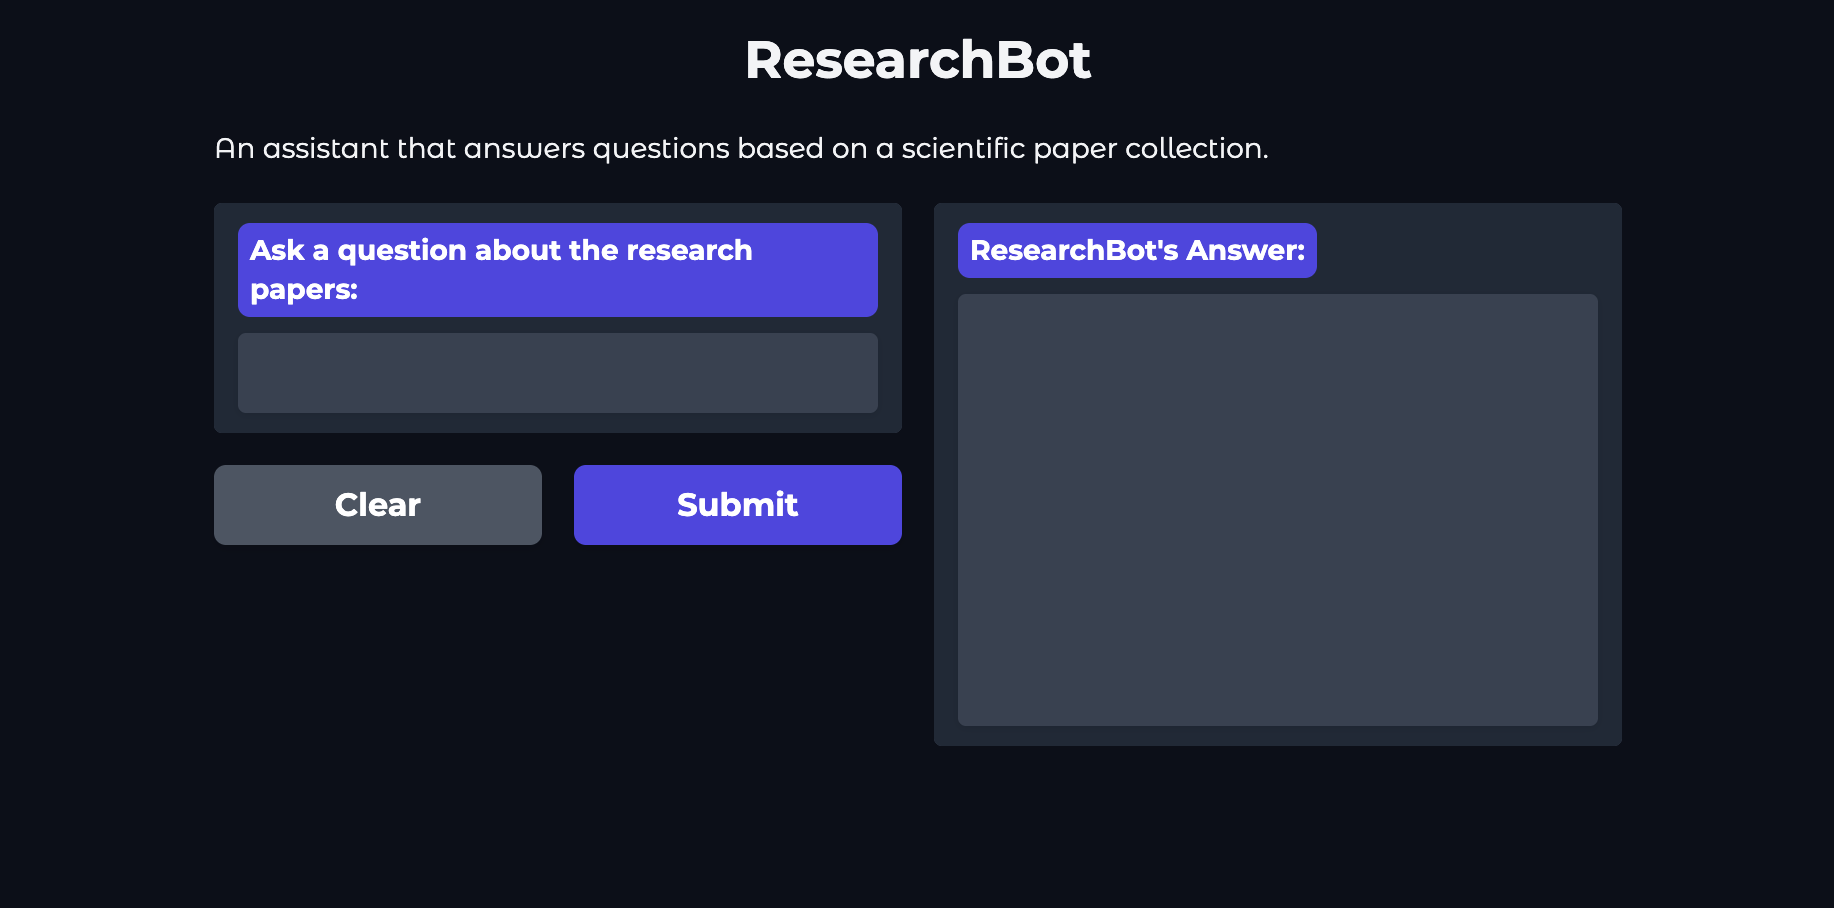

In [ ]:
def research_bot_interface(user_input):
    state = {
        "messages": [AIMessage(content=WELCOME_MSG)],
        "query": user_input,
        "retrieved_docs": [],
        "answer": "",
        "finished": False,
        "figures_retrieved": False,
    }

    if should_include_figures(user_input) and not state["figures_retrieved"]:
        state = images_table_agent(state)

    state = retriever_agent(state)
    state = answer_generator_agent(state)

    return state["answer"]

def main():
    gr.Interface(
        fn=research_bot_interface,
        inputs=gr.Textbox(label="Ask a question about the research papers:"),
        outputs=gr.Textbox(label="ResearchBot's Answer:", lines=10),
        title="ResearchBot",
        description="An assistant that answers questions based on a scientific paper collection.",
        theme="soft",
        allow_flagging="never"
    ).launch()

if __name__ == "__main__":
    main()

* Running on local URL:  http://127.0.0.1:7860
* To create a public link, set `share=True` in `launch()`.
